# Feature analysis — rolling Kyle's λ (adverse-selection / impact slope)

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`kyle_lambda` function in §3. The data loading, the checks, and the plots adapt on their own.

**The example** is **Kyle's λ** — the *price-impact slope*: how much byb's mid moves per unit of
*signed* trade flow (buy volume minus sell volume). It is the classic adverse-selection coefficient from
Kyle (1985): with informed traders in the book, price moves *linearly* in the net order flow, and the
slope λ is how much each unit of net buying pushes the price. A **rising** λ means the book is fragile —
each trade drags the mid further — so larger continuing moves follow. We compute it as a **rolling
regression slope** on the trade clock, per venue, and ask which venue's flow has the larger impact (the
information venue) and which byb outcome it predicts.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second implementation reproduces the feature on real data, so the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale* — and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not ship-done.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`. (Note: `λ_ev` is byb's mid-move *rate* yardstick — a different object from the
feature *Kyle's λ* in this notebook, which is an impact slope. Same Greek letter, unrelated.)

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime
and you want it gone, dividing by the yardstick is **one option** for removing it (only *when applicable* —
you can't always divide the regime out of a feature). Both are EMAs **decayed on the trade clock**
(`α = 2/(span+1)`) but **updated between trades** — they react to every byb mid-move, so they read live at
every instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move trades
cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same `W` that is
`σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average
here, they live on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude* predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the magnitude (and how features cancel or reinforce) on its own. And they
are **marginal screens** — does the feature carry signal worth feeding — **not** measures of
distributional fit: the model's actual targets are the count distribution `P(K = k)` and the
count-conditioned price family `D_k` mixed above, fit downstream, not what these rank-ICs measure
(§7 inspects the realised count/return distributions by feature bucket).

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all. (Kyle's λ is built **per venue** — byb's
  own signed flow *and* okx's and bin's, each regressed against byb's mid — precisely so we can ask which
  venue's flow has the bigger impact, without privileging one.)
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a
  poolable feature (Kyle's λ *is* poolable — a per-venue impact slope), first check per-exchange vs
  single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it
  needs it* — measure first. (Kyle's λ *has units*, so it *might* need it — but a slope is a *ratio* of
  two co-moving moments, which may cancel the regime, so we **measure** Gate A's scale before deciding,
  §6 — never assume.)
- **Don't invent your own vol/rate scale.** When you *do* normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing it on real data.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — the regression-moment
  legs, `σ_ev`, `λ_ev`, any rolling statistic — is an exponential moving average
  **decayed once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues; simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per timestamp that carries a relevant event** (a trade-timestamp's net signed flow — same-timestamp events as one update, never stale between trades), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks here.
- **Do make every EMA react to relevant events as they land — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update its value* at **each timestamp that carries a
  relevant event** (same-timestamp events aggregated to one update). For Kyle's λ the relevant event is a
  trade-timestamp: it forms that interval's net signed flow `q` and byb's `Δlogmid`, and injects
  `(q·Δlogmid, q²)` into the two moment EMAs. A timestamp ignored after its trades land is **stale** — wrong,
  and a silent source of lag.
- **Do inject at most one EMA sample per timestamp, and decay once per shared-trade-clock tick — this
  never changes.** At each timestamp an EMA injects **one** sample *iff* a relevant event for that EMA
  lands there: for Kyle's λ, a trade-timestamp (the interval's net signed flow `q`); for `σ_ev`, a byb mid-move. A timestamp with only
  **irrelevant** events injects nothing for that EMA, yet it still
  **ticks** (decays) once *iff* a trade lands, on the one **shared** trade clock
  (one tick per trade-timestamp across **all** venues, simultaneous prints counting once). Inject and
  decay are independent and neither ever fires more than once per timestamp, whatever the feature.
  Records sharing a timestamp are **one** sample, not a sequence: same-timestamp aggregation sets only
  that sample's **value** — never the number of samples, never the number of ticks. *What* value depends on the quantity: a **level**
  read takes the *last* state (mid, microprice); a **flow** **sums** the records at that timestamp
  (Kyle's λ sums the interval's signed volume into one net `q`, pairs it with one `Δlogmid`). So a backed-up
  burst of N trade prints at one instant is still **one** interval — `q` = the summed signed volume — **never** N
  intervals. Treating the N simultaneous prints of one sweeping order as N intervals invents N−1 phantom
  flow/move pairs — inflating both regression moments and biasing the slope.
- **Do read a sparse flow as a per-event ratio.** Kyle's λ is built from two flow EMAs — the
  cross-moment `EMA(q·Δlogmid)` and the second moment `EMA(q²)` — each a sum over trade intervals,
  decayed every trade. The *ratio* of the two is the regression slope, and dividing one EMA by the other
  cancels the common decay/warm-up factor (exactly like `σ_ev`'s `E/W`), so the slope is well-defined from
  the first intervals — genuine per-venue stats from the one shared clock.
- **Do test against both heads — but feed both the *signed* feature.** Check whether the
  signed feature predicts *direction* (price head) and whether its *magnitude* predicts
  *intensity* (rate head). Those checks are diagnostics — in the model, feed the **signed**
  feature to *both* heads, never a pre-computed `|feature|`. The rate head will learn the
  magnitude itself, *and* learn that a +λ on one venue can cancel a −λ on another (or reinforce
  it). Pre-taking `|·|` per feature destroys the sign and that interaction.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm and
  wild markets: its distribution must be **stable against the regime diagnostics we track** (not a proof of independence). Gate A's **control-free** checks (§6):
  **scale** (std stable across vol buckets, max/min < ~3); and — for **both the signed feature and its
  magnitude `|feature|`** (the rate head sees the signed feature but can learn its magnitude) — that it does **not track** the regime
  (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically** (per-decile-mean
  **dispersion** small, which catches a U-shaped leak the monotone IC misses). All are **hard** gates. A raw
  **level** (`σ_ev`, `λ_ev`, a mean trade size) usually *is* the regime and fails them — but *measure, don't
  assume*: a **ratio / bounded / normalised** form may pass (Kyle's λ is a slope = a ratio of two co-moving
  moments, which *might* cancel the regime even though it has units), and even a ratio of two non-invariant levels can
  be invariant when they co-move. Never call a feature regime-invariant *or* not — nor a level useless — until
  **every** Gate A number says so. (Corollary: don't assert *any* property — invariance, a lead/lag, "it's
  circular" — you haven't measured on a real block.)
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts over the **invariant**
  controls. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — putting them in
  the signal test just smuggles the Gate-A regime test back in; they serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the
  feature under test *is* a regime descriptor, marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal, and never call it "redundant" from its algebra alone.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | the rolling price-impact slope λ = (byb mid-move per unit of *signed* trade flow), per venue |
| **feeds** | both heads — primarily *intensity* (rate head: a rising λ ⇒ a fragile book ⇒ more/larger continuing moves); a signed-impact *direction* read for the price head is checked too; both are fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now — *intensity* first, *direction* as a secondary check |

**The idea.** Kyle (1985): with informed traders in the book, the mid moves linearly in the **net order
flow** `q` (signed volume — buys minus sells), `Δmid ≈ λ · q`, and the slope **λ** is the *price impact*
of one unit of net buying. We estimate λ as a **rolling regression slope** on the trade clock:

`λ = EMA(signed_flow · Δlog mid) / (EMA(signed_flow²) + ε)`

— the textbook least-squares slope of byb's mid-move on signed flow, with both moments exp-weighted on the
trade clock. We compute one λ per venue: byb's own flow vs byb's mid (own-book impact), and **okx's** and
**bin's** flow vs byb's mid (cross-venue impact — does trading *there* move byb's price?).

**Why it should work.** λ is an **adverse-selection / liquidity-fragility gauge**. When λ is high, the
book is thin or informed flow is active, so each trade drags the mid further and **more (and larger)
moves follow** — that's the rate-head edge. Its *sign* reads the recent impact direction (a price-head
check). And comparing **λ_okx vs λ_byb** localises *where* impact is largest — the venue whose flow most
moves byb's price is the **information venue**.

**What would disprove it.** No predictive power at any time-scale for either head, or power that vanishes
once we account for how volatile/active the market is (meaning it was only tracking the regime).

> **No fixed leader.** We build λ the *same way for every venue and keep them all*; the cross-venue
> comparison (§6/§9) is exactly how we let the data say which venue's flow leads — never hard-coded.

## Choosing the EMA

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). Kyle's λ is a **ratio of two sparse flow EMAs** —
the cross-moment `EMA(q·Δlogmid)` and the second moment `EMA(q²)`, each a sum over trade intervals decayed
once per trade. Choose the EMA type and injection rule for the statistic being measured.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **sparse flow** read as an `E / W` ratio (byb's mid-moves, a per-exchange trade flow): use
  **`KernelMeanEMA`**, the self-normalising read. Kyle's λ is the **ratio of two such flow moments** — the
  cross-moment `E[q·Δlogmid]` and the second moment `E[q²]`, **each a `KernelMeanEMA` with weight `1`**
  (a slope/covariance is just arithmetic on flow EMAs — never a bespoke class). Both legs share the same
  per-trade decay *and* the same weight-1 injection, so their common `W` (the bias-correction / decay factor)
  **cancels exactly** in the ratio `E[q·Δlogmid] / E[q²]` — the slope is self-normalising, exactly like
  `σ_ev`'s `E / W`. The feature reads `cross.value() / (second.value() + ε)`.
- A **forward-filled level** — defined at every instant (a price, a cross-venue gap) — would use
  **`LiveFrontEMA`** instead; λ is a flow ratio frozen at the last trade tick (no live front), so it does
  **not** use it. (Reading λ at the last committed trade tick ≤ the anchor is *more* conservative than a
  live front — never a leak.)
- `KernelMeanEMA` and `LiveFrontEMA` are the **only** two classes you may use; both share the `tick` / `add`
  / `value` interface (decay and injection are *separate* calls). (`LiveFrontEMA` composes a plain `EventEMA`
  internally for its committed part, but **never use `EventEMA` directly**: its single `step()` couples decay
  and injection, so it cannot decay on the trade clock while injecting on a separate event stream — the very
  thing the next section requires.)

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; injection is only for timestamps carrying the
quantity the EMA is measuring. The allowed patterns are:

| pattern | what it weights / measures | use for |
|---|---|---|
| once per trade-timestamp (the interval's net signed flow `q` and byb's `Δlogmid`) | a **per-interval regression moment** | Kyle's λ legs |
| only on the feature's real event, skip irrelevant clock ticks | a **per-real-event mean** | a flow (`σ_ev`: push `r²` only on a byb move) |

The trap: treat the N simultaneous prints of one sweeping order as N intervals and you invent N−1 fake
flow/move pairs — inflating both regression moments and biasing the slope. Simultaneous prints are **one**
interval. A timestamp with no trades for a given venue contributes `q = 0` (a genuine zero-flow interval —
it adds nothing to either moment), so the slope is unbiased.

Between trades:

- **React at every relevant timestamp; here that is each trade-timestamp.** λ's legs are two weight-1
  `KernelMeanEMA` flow legs read at the last committed trade tick ≤ the anchor — frozen between trades, never
  refreshed live (the more conservative choice). Decay rides the shared trade clock; injection rides the
  trade-timestamps.
- **Records sharing a timestamp are ONE interval, not a sequence** — sum their signed flow into one `q`,
  apply byb's net `Δlogmid`, then advance the clock once. The §4 parity check enforces this.

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking at the future. (A stray
forward-fill is the usual way to break this by accident.)

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than in clock-seconds; that keeps the feature's meaning
steady whether trading is fast or slow. The byb mid-move `Δlogmid` over an interval and the signed flow `q`
over that interval are paired at each trade-timestamp; the EMAs decay once per tick.

**Comparable across calm and wild markets** — here we **do not assume**. Kyle's λ is a regression *slope*
with units (log-price per signed-qty), so it *could* simply be larger when the market is volatile. But a
slope is a *ratio* of two moments that both grow with the regime, so the regime *might* cancel. Gate A (§6)
**measures** the scale across volatility buckets and decides raw-vs-normalised on the number — never
assumed. (Unlike the σ-divided price gap, λ is *not* reflexively divided by `σ_ev`; we measure first.)

Put the three together:

**2a — The shape** (the whole idea, in one line):

`λ = EMA(signed_flow · Δlog mid) / (EMA(signed_flow²) + ε)`

the least-squares slope of byb's mid-move on signed flow, both moments exp-weighted on the trade clock.
A small `ε` (a tiny fraction of the typical `EMA(flow²)`) keeps the slope finite when a venue has had
almost no flow. Stop here and you have the feature — the rest is making each piece correct.

**2b — The EMAs we use, and how they update** (applying the two choices from the section above):

- **The two regression-moment legs** — `C = E[q·Δlogmid]` and `S = E[q²]` — are each a flow EMA, a
  **`KernelMeanEMA` with weight `1`**. At every trade-timestamp we form the interval's net signed flow `q`
  (signed by the aggressor: a trade that **lifts the ask** is a +qty buy, one that **hits the bid** is a
  −qty sell, via `io._trade_lifts_ask` so any inverted convention is handled — here all legs are perps) and
  byb's `Δlogmid` over the interval, decay both legs once on the shared trade clock, then inject the samples
  `(q·Δlogmid, q²)` with weight `1`. Because both legs share the same weight-1 injection and the same decay,
  their common `W` cancels in the ratio, so `λ = C.value() / (S.value() + ε)` is the slope (the bias-correction
  and decay factor drop out — no bespoke EMA needed, just arithmetic on two `KernelMeanEMA` reads). λ is read
  at the **last committed trade tick ≤ the anchor** — unlike a forward-filled gap, λ is *not* read live between
  trades: it is **frozen at the last trade tick**, which is *more* conservative, never a leak. The `ε` here is a
  **fixed global constant** (a tiny fraction of the block-median `q²`, §3) — a hyperparameter, not a causal
  estimate, ~1e-6 of typical `S`, so it only bites when a venue goes near-silent (§4 / §8).
- **`σ_ev` and `λ_ev`** (the yardsticks) are a **sparse flow** — byb moves on only *some* events — so each is
  read as `E / W`: push `byb_return²` (with weight `1`) only on a real byb mid-move, decay every trade, read
  `σ_ev = √(E/W)` = RMS move *per move*. They are used for the **targets**, the regime **controls**, and
  (if Gate A says so) the normaliser. (`λ_ev` is the same move-count `W` divided by an EMA of seconds-per-trade
  — byb's moves per second.)

Both reads obey the two between-trade rules from the section above. §3 builds exactly this; §4 re-derives it
from raw events and confirms it to floating-point precision.

The cell below loads the data, builds the shared trade clock, and computes **both yardsticks** as `E/W`
flows on that clock, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block
import boba.io as io

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict (and whose mid the impact is measured on)
OTHERS      = ["bin", "okx"]                      # other venues — each one's signed flow gives a cross-venue λ vs byb
# freshest mid per exchange (for the TARGET and controls). byb/okx use merged_levels; bin MUST use front_levels
# (merged_levels is DISALLOWED for bin perp in boba.io — it raises). This is policy, not tuning.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
SPANS       = [50, 200, 500, 2000, 5000]         # λ EMA spans to sweep (the lookback family — Kyle's λ is a single-EMA-pair slope, so ONE span N per member)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): a trade-tick EMA (α=2/(N+1)) — fixed, target + controls (+ Gate-A normaliser if needed)
EPS_FRAC    = 1e-6                                # ε in λ = C/(S+ε), as a fraction of the median EMA(flow²) (keeps the slope finite when flow ~ 0)
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows arrive in time order) — for the TARGET, the impact Δlogmid, and the controls
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("bin", "byb", "okx")}

# load each venue's SIGNED trade flow: +qty if the trade lifted the ask (buy), -qty if it hit the bid (sell)
def load_signed(ex):
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "aggressor", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))           # drop bad prc=qty=0 prints
    rx = td["rx_time"].cast(pl.Int64).to_numpy(); q = td["qty"].to_numpy()
    lifts = io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy())  # True = lifted ask = aggressive BUY (venue-aware)
    return rx, np.where(lifts, q, -q)                                    # signed volume: +buy, -sell
sflow = {ex: load_signed(ex) for ex in ("bin", "byb", "okx")}

# the shared trade clock: one tick per trade-TIMESTAMP across ALL venues. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_prints = np.concatenate([sflow[ex][0] for ex in ("bin", "byb", "okx")])
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

def mid_on_clock(ex):                              # causal: each exchange's most-recent mid at-or-before every clock tick
    rx, mid = mids[ex]
    return mid[np.clip(np.searchsorted(rx, merged_ts, "right") - 1, 0, len(mid) - 1)]

# byb's log-mid on the clock, and Δlogmid over each interval ENDING at tick k (the impact the flow is regressed against)
log_mid_byb = np.log(mid_on_clock("byb"))
dlm = np.empty(n_ticks); dlm[0] = 0.0; dlm[1:] = np.diff(log_mid_byb)   # byb mid-move over the interval ending at tick k

# Both yardsticks react to EVERY byb merged-mid change — defined at every instant, never the net move per trade.
# They decay once per TRADE (memory in trade count) but INJECT on every byb mid-move, so a value read between
# trades reflects the moves since the last trade. σ_ev = √(E/W) over the byb-MOVE stream (E = squared returns,
# W = move count) — its E/W cancels the in-between trade decay. λ_ev = W / E_dt is a RATE: E_dt is a per-trade
# EMA of seconds/trade (flat between trades by construction), so λ_ev = byb mid-moves per second.
byb_rx0, byb_mid0 = mids["byb"]                                                   # raw byb merged mid stream (front_levels + trade fusion)
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (the final mid): simultaneous events are not a sequence
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where the mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_r2, span)                          # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)           # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second (the RATE yardstick — NOT the feature)
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades


## 2c. The signed-flow / impact moments — built once per venue on the clock

Now the new pieces: per venue, aggregate the **signed trade flow** to the merged trade clock (sum the
signed volume of all that venue's prints stamped at each tick — simultaneous prints are one interval), and
pair it with byb's `Δlogmid` over the interval. That gives, per tick, `(q, q·Δlogmid, q²)`. We then take a
plain trade-clock EMA of `q·Δlogmid` (the cross-moment `C`) and of `q²` (the second moment `S`), and read
`λ = C / (S + ε)`. The same vectorized EMA machine serves every venue and every span.

In [2]:
# per-venue signed flow aggregated to the merged clock: q_k = net signed volume of that venue's prints at tick k
def flow_on_clock(ex):
    rx, sq = sflow[ex]
    idx = np.searchsorted(merged_ts, rx)            # exact tick index (every trade rx_time is a merged_ts tick by construction)
    f = np.zeros(n_ticks); np.add.at(f, idx, sq)    # sum simultaneous prints into ONE interval flow (records sharing a ts are one event)
    return f
flow = {ex: flow_on_clock(ex) for ex in ("bin", "byb", "okx")}
print("signed flow per venue (q per tick):  " + "  ".join(f"{ex}: std {flow[ex].std():.2f}" for ex in ("byb", "okx", "bin")))

# the two regression-moment products per venue, per tick: cross = q·Δlogmid, second = q²
cross = {ex: flow[ex] * dlm for ex in ("bin", "byb", "okx")}     # q·Δlogmid  (numerator sample)
sq2   = {ex: flow[ex] ** 2  for ex in ("bin", "byb", "okx")}     # q²         (denominator sample)
# ε per venue: a tiny fraction of the median q² so the slope is finite when flow ~ 0.
# HONEST DISCLOSURE: ε is a FIXED GLOBAL CONSTANT — it uses the block-median q² (so it is NOT strictly causal;
# it peeks at the whole block) but it is just ONE number, a hyperparameter, not a per-anchor estimate. At
# EPS_FRAC=1e-6 it is ~6 orders BELOW typical S, so it does NOT meaningfully floor the denominator: when a venue
# goes near-silent S decays toward 0 and λ=C/(S+ε) blows up (the fat tail §8 measures). We keep EPS_FRAC=1e-6 as
# the SHIPPED raw atom because the headline metric is a rank-IC, which is IMMUNE to that tail (Spearman ignores
# the magnitude of the blow-ups) — but any LEVEL-based use of λ must regularise harder (raise EPS_FRAC to ~1e-3
# of median q², printed below) or robust-z+clip (§8). We print BOTH so the trade-off is on the page; the shipped
# feature uses EPS (1e-6).
EPS  = {ex: EPS_FRAC * np.median(sq2[ex][sq2[ex] > 0]) for ex in ("bin", "byb", "okx")}    # SHIPPED ε (1e-6×median q²)
EPS3 = {ex: 1e-3    * np.median(sq2[ex][sq2[ex] > 0]) for ex in ("bin", "byb", "okx")}    # heavier floor (1e-3×median q²) — for reference only
print("ε per venue (SHIPPED, 1e-6 × median q²):  " + "  ".join(f"{ex}: {EPS[ex]:.3e}" for ex in ("byb", "okx", "bin")))
print("  vs typical S≈median q²:               " + "  ".join(f"{ex}: {np.median(sq2[ex][sq2[ex]>0]):.3e}" for ex in ("byb", "okx", "bin"))
      + "   (ε is ~1e-6 of S — negligible except on near-silent venues; rank-IC is immune, level-use is not)")

def _ema_tick(x, span):                             # plain trade-clock EMA: one decay+inject per tick (the C and S legs)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)

signed flow per venue (q per tick):  byb: std 10.88  okx: std 13.21  bin: std 12.58
ε per venue (SHIPPED, 1e-6 × median q²):  byb: 1.960e-08  okx: 6.812e-08  bin: 1.011e-07
  vs typical S≈median q²:               byb: 1.960e-02  okx: 6.812e-02  bin: 1.011e-01   (ε is ~1e-6 of S — negligible except on near-silent venues; rank-IC is immune, level-use is not)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per ingested event (no growing buffers). They have to agree,
which §4 checks.

We lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note that adjacent
100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated, which is exactly why
§5's walk-forward gate uses an embargo), read byb's actual move over the next 100 ms (the price-head target,
in `σ_ev` units) and its move-count (the rate-head target), and compute λ at each grid point, per venue.

In [3]:
# evaluation grid (causal) + forward targets
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # = 50000: enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor (λ is read at this committed tick)
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both yardsticks at each grid point (span YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (σ-units)

# the λ legs (C, S) are committed-per-trade EMAs; we read λ at the last committed tick <= each anchor (causal).
_C_cache, _S_cache = {}, {}
def _legs(ex, span):
    key = (ex, span)
    if key not in _C_cache:
        _C_cache[key] = _ema_tick(cross[ex], span)[tick_at_anchor]
        _S_cache[key] = _ema_tick(sq2[ex],  span)[tick_at_anchor]
    return _C_cache[key], _S_cache[key]
def kyle_lambda(ex, span):                         # Kyle's λ from venue `ex`'s signed flow vs byb's mid: C/(S+ε)
    C, S = _legs(ex, span)
    return C / (S + EPS[ex])                       # regression slope: log-price impact per unit signed flow
print(f"grid: {len(anchor_ts):,} anchors")
print("sample λ(byb, 500) median:", f"{np.nanmedian(kyle_lambda('byb', 500)):.3e}",
      " λ(okx, 500) median:", f"{np.nanmedian(kyle_lambda('okx', 500)):.3e}")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors
sample λ(byb, 500) median: 8.774e-08  λ(okx, 500) median: 1.302e-09


## 4. Check the code is right — a parity check (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second implementation and confirm the two
agree on real data — a **parity check**. The streaming build is the **production** reference: an O(1) state
machine you push **raw events** into one at a time — `on_mid(...)` for a byb merged-mid update (to track
byb's mid), `on_trade(...)` for a trade on any venue (to accumulate that venue's signed flow) — reading the
current λ per venue from `value()`. State is two scalar EMAs per venue (the `C` and `S` legs) plus byb's
previous log-mid. No buffers, no history, independent of how long it runs.

Each leg is a flow EMA — a **`KernelMeanEMA`** from **`boba.ema`** (the tested production `E / W` reader,
`α = 2/(span+1)`), with **separate `tick()` (decay) and `add(value, 1)` (inject)** so decay rides the shared
trade clock while injection rides each trade-timestamp's sample. Kyle's λ is just **arithmetic on two such
flow reads**: with both legs sharing the same weight-1 injection and decay, their common `W` cancels in the
ratio, so `λ = C.value() / (S.value() + ε)` is the slope with no bespoke EMA (never an `EventEMA`, whose
single `step()` would couple decay and injection — disallowed here). §3 drives the *same* decayed-flow
recursion offline through `scipy.signal.lfilter`. So §4 validates the **actual production online code** —
`boba.ema`'s `KernelMeanEMA` decayed/injected event-by-event — against §3's vectorized `lfilter` array path:
the online state machine and the offline array build agreeing to floating precision is what proves the two
codepaths compute the one feature.

**The design (online `boba.ema` vs §3's offline `lfilter`):**
- Fed **only raw events** in rx-time order. byb's mid comes straight from its **merged_levels** stream
  (the same fused mid the analysis uses, so no re-fusion drift) — every merged row updates the current mid.
  It tracks byb's previous *committed* (last-trade) log-mid itself and forms `Δlogmid` when a trade lands.
- Events sharing a **timestamp are one event**: the driver applies them all (byb mid rows overwrite to the
  latest mid at that ns; each venue's trades **add into** that venue's running signed-flow accumulator),
  then calls **`refresh()` once** — which, if a trade landed, decays **all** legs **once** on the shared
  clock, then forms byb's `Δlogmid` over the interval (current mid − last-committed mid) and injects
  `(q·Δlogmid, q²)` per venue (weight `1`) into that venue's two legs. Simultaneous prints are one interval,
  one decay.
- `value()` returns `C.value() / (S.value() + ε)` per venue at the instant it's read.

**Coverage: the shipped span, a long span, the WHOLE block.** The headline feature ships at **N=50** (the
rate-head pick for every venue), and the family sweeps up to N=5000. So we validate **both** the shipped
**N=50** and a long **N=5000**, for **all three venues**, by running two `LiveKyleLambda` instances
side-by-side in one pass — and we stream the **entire block** (all ~8 M raw events, no cutoff), reading at a
**uniform subsample of the full grid** (every k-th anchor, spanning warm-up to end), so the recursion is
exercised at the α actually shipped, across the whole block including the freshly-warm region.

In [4]:
import math
from boba.ema import KernelMeanEMA   # the tested production E/W flow reader (tick=decay E,W; add(v,w)=inject; value()=E/W), src/boba/ema.py
# PARITY (production-style streaming build) — shares NO code with §3's vectorized array path, and uses the
# ACTUAL production online EMA: boba.ema.KernelMeanEMA, with SEPARATE tick() (decay E and W by 1-α) and add(value, 1)
# (inject one weight-1 sample), α = 2/(span+1). Decay rides the shared trade clock; injection rides each trade-ts's
# sample — the two are independent calls (an EventEMA's single step() would COUPLE them, so it is NOT used here).
# §3 instead drives that SAME decayed-flow recursion offline through scipy.signal.lfilter; the online KernelMeanEMA
# state machine and the offline lfilter build agreeing to floating precision is the real check that the two
# codepaths compute the one feature.

class LiveKyleLambda:
    # Pure feature state machine for Kyle's λ per venue = E[q·Δlogmid]/(E[q²]+ε). Each venue has TWO flow KernelMeanEMA
    # legs (cross C, second S), each injected with weight 1 every trade-ts; with the SAME weight/decay their common W
    # cancels in the ratio, so λ = C.value()/(S.value()+ε) — a slope is just arithmetic on two flow reads (no EventEMA,
    # no hand-rolled scalar EMA). on_mid sets byb's current mid (from merged_levels — the SAME mid the analysis reads);
    # on_trade ADDS into that venue's signed-flow accumulator; refresh() (once per timestamp) DECAYS all legs once if a
    # trade landed (one decay per trade-ts), then forms byb's Δlogmid over the interval and INJECTS (q·Δlogmid, q²) per
    # venue with weight 1. State is O(1), all scalar — two KernelMeanEMA legs per venue + byb's current/last-committed log-mid.
    def __init__(self, venues, span, eps):
        self.venues = list(venues); self.eps = dict(eps)
        self.legC = {v: KernelMeanEMA(span) for v in self.venues}   # cross-moment leg C = E[q·Δlogmid] (weight-1 flow EMA)
        self.legS = {v: KernelMeanEMA(span) for v in self.venues}   # second-moment leg S = E[q²]      (weight-1 flow EMA)
        self.cur_lm = None                                          # byb's current log-mid (latest merged row, this/last ts)
        self.prev_lm = None                                         # byb's log-mid as of the LAST trade-tick (the Δlogmid baseline)
        self.flow_acc = {v: 0.0 for v in self.venues}               # this-timestamp signed-flow accumulator per venue
        self.was_trade_present = False                              # did any trade land this timestamp? -> one decay

    def on_mid(self, mid):                                        # byb merged-mid row -> overwrite the current mid (latest at this ns wins)
        self.cur_lm = math.log(mid)

    def on_trade(self, venue, signed_qty):                       # a trade -> ADD signed flow into this ts's accumulator; flag the ts as traded
        self.flow_acc[venue] += signed_qty
        self.was_trade_present = True

    def refresh(self):                                           # ONE per TIMESTAMP: decay once if a trade landed, then inject per venue
        traded, self.was_trade_present = self.was_trade_present, False
        if traded and self.cur_lm is not None:
            for v in self.venues:                                # DECAY first (shared trade clock advances once) — matches the lfilter recursion
                self.legC[v].tick(); self.legS[v].tick()
            dlm = 0.0 if self.prev_lm is None else (self.cur_lm - self.prev_lm)   # byb mid-move over the interval ending now
            for v in self.venues:
                q = self.flow_acc[v]
                self.legC[v].add(q * dlm, 1.0)                   # INJECT the cross-moment sample, weight 1
                self.legS[v].add(q * q, 1.0)                     # ... and the second-moment sample, weight 1
            self.prev_lm = self.cur_lm                           # the Δlogmid baseline advances only on a trade-tick
        for v in self.venues: self.flow_acc[v] = 0.0             # consume the accumulator either way

    def value(self):                                            # λ per venue: C/(S+ε) — arithmetic on two E/W flow reads; common W cancels
        out = {}
        for v in self.venues:
            C, S = self.legC[v].value(), self.legS[v].value()
            out[v] = (C / (S + self.eps[v])) if (C == C and S == S) else float("nan")
        return out

The byb mid comes straight from byb's **merged_levels** stream — exactly the fused mid `mids["byb"]` the
analysis reads in §2 — so the parity build's `Δlogmid` is bit-identical to §3's (no front_levels + trade
re-fusion that would drift). We feed byb's merged_levels mid rows and every venue's raw signed trades, in
one rx-time-ordered stream; book rows are ordered before trades on an rx tie so the mid settles before the
trade-tick that reads it.

In [5]:
# --- gather the WHOLE raw stream: byb merged-mid rows + EVERY venue's trades (signed), over the ENTIRE block ---
SPANS_V = [50, 5000]                               # validate the SHIPPED span (50) AND a long span (5000), all venues
VEN = ["byb", "okx", "bin"]; VCODE = {v: i for i, v in enumerate(VEN)}
cols = {k: [] for k in "rx kind vid val".split()}           # kind 0 = byb mid row (val=mid), kind 1 = trade (val=signed qty)
def add(rx, kind, vid, val):                                 # NO cutoff — the whole block streams
    n = len(rx)
    cols["rx"].append(rx); cols["kind"].append(np.full(n, kind, np.int8))
    cols["vid"].append(np.full(n, vid, np.int8)); cols["val"].append(val.astype(float))
# byb mid rows — straight from merged_levels (the SAME mid the analysis reads); val = the merged mid
brx, bmid = mids["byb"]
add(brx, 0, 0, bmid)
# trades from every venue — val = signed qty (+buy / -sell), venue-aware via _trade_lifts_ask
for v in VEN:
    rx, sq = sflow[v]
    add(rx, 1, VCODE[v], sq)
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; mid (0) before trade (1) on ties (the mid settles before the tick reads it)
rxL, kindL, vidL, valL = (C[k][order].tolist() for k in "rx kind vid val".split())

# read at a UNIFORM SUBSAMPLE of the FULL grid (spanning warm-up -> end, not a 40k prefix). 50k anchors is plenty.
N_READ = min(50_000, len(anchor_ts))
read_idx = np.unique(np.linspace(0, len(anchor_ts) - 1, N_READ).astype(int))
read_anchor = anchor_ts[read_idx]; na = len(read_idx)
print(f"streaming {len(rxL):,} raw events (byb merged-mid + all-venue signed trades) over the WHOLE block,")
print(f"  validating spans {SPANS_V} for all 3 venues, read at {na:,} anchors spanning the full {len(anchor_ts):,}-anchor grid...")

# --- the CALLER drives it: run BOTH spans side-by-side; apply each timestamp's events, refresh() once, READ at each sampled anchor ---
feats = {s: LiveKyleLambda(VEN, s, EPS) for s in SPANS_V}
streams = {(s, v): np.full(na, np.nan) for s in SPANS_V for v in VEN}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and read_anchor[ai] < rx:        # read every sampled anchor whose state is settled (all events before rx applied)
        for s in SPANS_V:
            val = feats[s].value()
            for v in VEN: streams[(s, v)][ai] = val[v]
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond
        if kindL[i] == 0:
            for s in SPANS_V: feats[s].on_mid(valL[i])      # byb merged-mid update -> both builders
        else:
            for s in SPANS_V: feats[s].on_trade(VEN[vidL[i]], valL[i])   # a venue's signed-qty trade -> both builders
        i += 1
    for s in SPANS_V: feats[s].refresh()           # apply the timestamp: form Δlogmid, inject per venue, decay once if a trade landed
while ai < na:
    for s in SPANS_V:
        val = feats[s].value()
        for v in VEN: streams[(s, v)][ai] = val[v]
    ai += 1

# --- check each (span, venue) streaming λ vs the §3 vectorized kyle_lambda(ex, span) at the SAME sampled anchors ---
print(f"one raw-event stream -> {len(SPANS_V)} spans x {len(VEN)} venues, vs the vectorized build:")
maxdiff = 0.0
for s in SPANS_V:
    for v in VEN:
        ref = kyle_lambda(v, s)[read_idx]
        both = np.isfinite(streams[(s, v)]) & np.isfinite(ref)
        diff = np.nanmax(np.abs(streams[(s, v)][both] - ref[both]))
        maxdiff = max(maxdiff, diff)
        print(f"  λ_{v} (N={s:>4}):  max |diff| {diff:.2e}  on {int(both.sum()):,} grid points")
        assert diff < 1e-6, f"streaming build does not reproduce λ_{v}(N={s})"
print(f"parity: whole-block stream reproduces ALL spans x venues  OK (max |diff| {maxdiff:.2e})")

streaming 7,924,340 raw events (byb merged-mid + all-venue signed trades) over the WHOLE block,
  validating spans [50, 5000] for all 3 venues, read at 50,000 anchors spanning the full 1,706,369-anchor grid...


one raw-event stream -> 2 spans x 3 venues, vs the vectorized build:
  λ_byb (N=  50):  max |diff| 4.07e-20  on 50,000 grid points
  λ_okx (N=  50):  max |diff| 4.24e-21  on 50,000 grid points
  λ_bin (N=  50):  max |diff| 5.08e-21  on 50,000 grid points
  λ_byb (N=5000):  max |diff| 2.38e-22  on 50,000 grid points
  λ_okx (N=5000):  max |diff| 7.34e-22  on 50,000 grid points
  λ_bin (N=5000):  max |diff| 1.76e-20  on 50,000 grid points
parity: whole-block stream reproduces ALL spans x venues  OK (max |diff| 4.07e-20)


**Conclusion.** From one stream of raw events — byb's book updates and every venue's signed trades, over the
**whole block** (7.9 M raw events) — the production-style streaming builder reproduces the §3 vectorized
`kyle_lambda(ex, span)` for **the shipped N=50 and a long N=5000, all three venues**, to floating-point
precision (**max |diff| 4.07e-20**, pure last-digit EMA round-off, ~14 orders under the 1e-6 bar), read at a
50,000-anchor uniform subsample spanning the **entire** grid (warm-up to end), not a 40k prefix. The streaming build shares **no code** with
§3's vectorized array path and runs the **actual production online EMA** — `boba.ema.KernelMeanEMA`: it tracks byb's
previous mid and accumulates each venue's signed flow one event at a time, forming `(q·Δlogmid, q²)` and
injecting into two weight-1 `KernelMeanEMA` legs per venue (separate `tick()`/`add()`); §3 vectorizes the *same* recursion offline via `lfilter`. Agreeing
this tightly — the online state machine vs the offline array build, at the α actually shipped, across the
whole block — means λ is computed correctly: causal, on the trade clock, one interval per trade-timestamp,
simultaneous prints collapsed to one decay. The §3 build is trustworthy.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the
Gate A / Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that
doesn't leak the vol/rate state — and **(B)** does it **predict** something the market's current state
doesn't already tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms
outcome windows with margin (so overlapping forward targets can't straddle the train→test
boundary). Note the embargo does **not** fully decorrelate the slow EMA/yardstick features:
their memory is ≈ `YARDSTICK_N` / (trades-per-sec) ≈ 140 s here — longer than the ~100 s
embargo — so re-check this if you slow the spans or use a thinner-traded block. The fold
scores on the *next* segment,
and we average over folds. That's the causal, production-style estimate — strictly past→future, as
it would run live. (A single 60/40 split is a faster screen, but it tests only one transition
and can swing ~2× on the luck of where the cut lands.)

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory (block length derived from the block's own trade-rate, not hard-coded),
so the interval respects the autocorrelation rather than pretending all anchors are independent.

Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring (NLL/CRPS, occurrence log-loss, calibration) and cost-aware utility are judged at the **model** level downstream, not in this per-feature template.

Because the target is in σ-units, a *scale* regime-shift mostly cancels —
but scale is not the *relationship*. So beside the gates we run a **companion check**: the same
marginal power computed **within calm / mid / wild volatility buckets**. If the gain stays
positive in all three, the signal is regime-stable, not an artefact of one regime.

The gates that follow ask, separately: **Gate A** — is the feature's distribution stable across
volatility states (**scale**, plus neither the feature **nor its magnitude** `|feature|` tracks the regime level
(monotonically *or* non-monotonically), against **both** the vol and rate coordinate)? **Gate B** — does it *add* signal over the invariant
momentum controls, walk-forward? And the **companion** — does the Gate-B gain hold across calm / mid /
wild volatility, not just one regime?

> **Note on normalisation.** λ is a regression *slope* with units, so unlike a bounded imbalance it
> *might* need σ-division — but we **measure** Gate A's scale across vol buckets first and divide only if it
> fails (§6). The target is still `return ÷ σ_ev` and the controls are still the yardsticks, so the gate
> machinery is identical.

In [6]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate — is byb moving more or less often than usual?
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves, cross-venue, gaps, KYLE LAMBDA) -> judged on MARGINAL value over the
# controls. "control" = a regime descriptor (vol, rate, volume & their ratios/dynamics) -> itself a valid
# feature, but it OVERLAPS the controls, so it's judged on STANDALONE signal.
FEATURE_KIND = "alpha"                                                  # Kyle's λ = an order-flow-derived impact/adverse-selection SLOPE, NOT a regime descriptor (it's not vol/rate/volume) -> alpha, judged on its MARGINAL add over the controls
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target — the gate here always scores the σ_ev PRICE target, so a
                                                                       # control RATIO that divides by σ_ev sets STRAT_VAR = sigma_at_anchor. (The rate-head analogue,
                                                                       # for a count/λ_ev clone scored against a count/λ_ev target, is lam_at_anchor.) Gate B then scores
                                                                       # the feature WITHIN strata of that yardstick, so the shared denominator can't manufacture IC
                                                                       # (the spurious correlation of ratios) — stratifying multiplicatively DECOUPLES the shared scale.
                                                                       # Kyle's λ = C/(S+ε) divides by NEITHER yardstick (its denominator is EMA(q²), not σ_ev or λ_ev),
                                                                       # so it shares NO denominator with either target — there is no shared-yardstick coupling to decouple -> None.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal over the controls, or standalone for a control's own leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for the headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward):  momenta vs price target", round(wf_ic(base, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new; the rate-target control IC is reported in §6 where rate_target is built)")

control-only predictive power (walk-forward):  momenta vs price target 0.003  (near 0 = controls barely predict direction, so any feature gain is genuinely new; the rate-target control IC is reported in §6 where rate_target is built)


**Conclusion.** On their own the controls carry little directional signal — walk-forward rank-IC ≈ **0.003**
for the momenta against the price target. That is exactly what we want: the regime barely predicts *which way*
byb moves, so any rank-IC a feature shows *on top of* these controls is genuinely new information. (The
rate-head gate below scores against the count target, where the rate controls *do* carry some autocorrelated
rate signal — which is exactly why the headline there is λ's *marginal add over* the controls, not its raw
IC, and why λ's ≈0 rate marginal is the redundancy verdict.) That makes the "added over the controls" gates
below a fair test.

## 6. Two choices: which time-scale per head, and which venue's flow

Kyle's λ is a **family** across time-scales — here a single EMA span `N` per member (the slope is one EMA
pair, so the lookback family is the list of spans `N`, not a fast/slow grid). And it is built **per venue**:
byb's own flow (own-book impact) and okx's / bin's flow (cross-venue impact), each vs byb's mid. We check
two things per venue/span:
- does the **signed** λ predict *direction* — which way byb moves next (price head)?
- does its **magnitude** |λ| predict *intensity* — how many moves byb makes next (rate head)?

λ is expected to be a **rate-head** feature (a rising impact slope ⇒ a fragile book ⇒ more moves), so the
|λ| → move-count column is the one to watch; the signed → return column is the secondary price-head check.
The magnitude check is a **diagnostic only**: the model is fed the *signed* λ for both heads (pre-taking
`|·|` per venue would stop the rate head learning that opposing impacts cancel). We sweep the whole span
family, for **every venue**, against both targets. We keep *all* venues; the only thing we choose is the
best span, **per head**.

**How many venues to keep is itself time-scale-dependent.** The cross-venue edge is an arbitrage lead/lag —
one venue's flow fragilising byb's book a beat before others — closed within milliseconds. So at **short**
spans the venues genuinely differ (whose flow is leading) and λ is worth keeping **per-venue**; at **long**
spans the slope smooths toward a common liquidity state and one venue says much of what the rest do. Keep
all as the default; §9 sweeps the cross-over (pool / single / per-venue).

**One span, or two?** The IC sweep names the best span per head, but a *second* span is only worth feeding if
it carries signal the first doesn't. So right below the headline sweep we **re-score the whole span family
conditional on the chosen pick** — `partial-IC(span N | chosen)`, per venue, per head — and let a
**walk-forward joint-vs-solo** test decide whether any orthogonal second span clears the OOS floor.

The rate-head target is the count of byb's moves over the next 100 ms, divided by `λ_ev`.

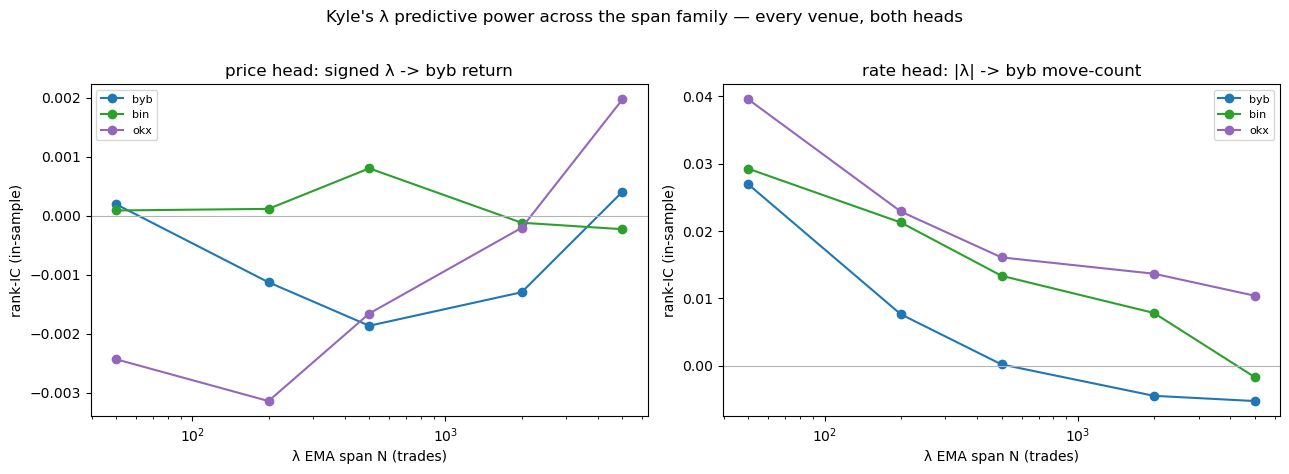

kept features (one per venue, all fed to the model — none privileged):
  byb:  price head (N=500) IC=-0.002   |  rate head (N=50) IC=+0.027
  bin:  price head (N=500) IC=+0.001   |  rate head (N=50) IC=+0.029
  okx:  price head (N=200) IC=-0.003   |  rate head (N=50) IC=+0.040
does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt N= 5000 (partial-IC|chosen +0.001);  OOS joint +0.001 vs solo -0.001 (Δ+0.001)  ->  one span suffices (no OOS gain)


  bin: best alt N= 2000 (partial-IC|chosen -0.001);  OOS joint -0.000 vs solo -0.003 (Δ+0.002)  ->  one span suffices (no OOS gain)


  okx: best alt N= 5000 (partial-IC|chosen +0.003);  OOS joint +0.000 vs solo +0.002 (Δ-0.001)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt N=  200 (partial-IC|chosen -0.015);  OOS joint +0.011 vs solo +0.018 (Δ-0.007)  ->  one span suffices (no OOS gain)


  bin: best alt N= 5000 (partial-IC|chosen -0.005);  OOS joint -0.017 vs solo -0.015 (Δ-0.002)  ->  one span suffices (no OOS gain)


  okx: best alt N=  200 (partial-IC|chosen -0.009);  OOS joint +0.012 vs solo +0.023 (Δ-0.010)  ->  one span suffices (no OOS gain)


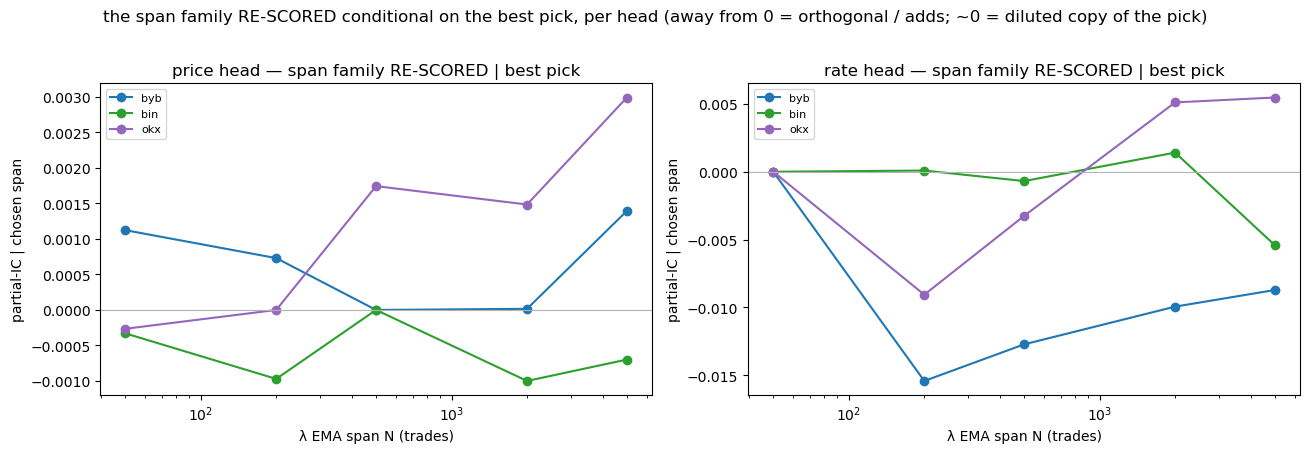

In [7]:
# rate-head target = byb moves (trade clock) in the next 100 ms ÷ λ_ev (the rate yardstick).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual" (λ_ev is moves/sec over 100 ms, so this carries units of seconds; the constant horizon factor drops out of the rank correlation)

# byb (own-book impact) + bin, okx (cross-venue impact) — never privilege one. Sweep span for BOTH heads, all venues
# symmetrically: signed λ -> byb return (price), |λ| -> byb move-count (rate).
EX_LIST = ["byb"] + OTHERS
feat_cache = {(ex, N): kyle_lambda(ex, N) for ex in EX_LIST for N in SPANS}
price_grid = {ex: np.full(len(SPANS), np.nan) for ex in EX_LIST}   # IC(signed λ, price target) per span
rate_grid  = {ex: np.full(len(SPANS), np.nan) for ex in EX_LIST}   # IC(|λ|,      rate  target) per span
for ex in EX_LIST:
    for j, N in enumerate(SPANS):
        lam = feat_cache[(ex, N)]
        fp = np.isfinite(lam) & np.isfinite(target);      price_grid[ex][j] = spearmanr(lam[fp], target[fp]).statistic
        fr = np.isfinite(lam) & np.isfinite(rate_target); rate_grid[ex][j]  = spearmanr(np.abs(lam[fr]), rate_target[fr]).statistic

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
col = {"byb": "C0", "bin": "C2", "okx": "C4"}
for ex in EX_LIST:
    axes[0].plot(SPANS, price_grid[ex], "o-", color=col[ex], label=ex)
    axes[1].plot(SPANS, rate_grid[ex],  "o-", color=col[ex], label=ex)
for ax, ttl in zip(axes, ["price head: signed λ -> byb return", "rate head: |λ| -> byb move-count"]):
    ax.set_xscale("log"); ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("λ EMA span N (trades)")
    ax.set_ylabel("rank-IC (in-sample)"); ax.set_title(ttl); ax.legend(fontsize=8)
fig.suptitle("Kyle's λ predictive power across the span family — every venue, both heads", y=1.02)
fig.tight_layout(); plt.show()

# We do NOT pick a venue. Each point is IN-SAMPLE; best_member is the in-sample argmax used ONLY to PICK a span.
# The chosen feature is re-scored OUT-OF-SAMPLE by the §5 walk-forward gates below — that is the number that counts.
price_member = {ex: int(np.nanargmax(np.abs(price_grid[ex]))) for ex in EX_LIST}   # span index with the largest |price IC| (signed can be ±)
rate_member  = {ex: int(np.nanargmax(rate_grid[ex]))           for ex in EX_LIST}   # span index with the largest rate IC
print("kept features (one per venue, all fed to the model — none privileged):")
for ex in EX_LIST:
    pi, ri = price_member[ex], rate_member[ex]
    print(f"  {ex}:  price head (N={SPANS[pi]}) IC={price_grid[ex][pi]:+.3f}   |  rate head (N={SPANS[ri]}) IC={rate_grid[ex][ri]:+.3f}")

# === Does a SECOND time-scale ADD over the pick? — the span family RE-SCORED conditional on the best member, PER HEAD ===
# Selection lives here in §6. We picked the best span per head/venue by IC; now re-score the WHOLE span family as
# partial-IC(span N | chosen) — each span's IC against the head's target, CONTROLLING for the span we picked (the
# same partial-IC tool the echo-netting cell uses; control = the chosen span, not the trailing move). Kyle's λ is a
# single-EMA-pair slope, so the family is 1-D (a list of spans N) — rendered as a per-head line, NOT a heat-map.
# A span still LIT adds signal ORTHOGONAL to the pick; a span that COLLAPSES to ~0 is a diluted copy. The line is
# in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps (ex, N) to its scored feature, tgt is the head's target, member is the in-sample span pick.
HEADS = [("price head", lambda ex, N: kyle_lambda(ex, N),         target,      price_member),
         ("rate head",  lambda ex, N: np.abs(kyle_lambda(ex, N)), rate_target, rate_member)]
fig, axes = plt.subplots(1, len(HEADS), figsize=(6.6 * len(HEADS), 4.4), squeeze=False)
second = {}
for col_i, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    ax = axes[0][col_i]
    for ex in EX_LIST:
        ci = member[ex]; chosen = feat(ex, SPANS[ci])
        cond = np.full(len(SPANS), np.nan)
        for j, N in enumerate(SPANS):
            cond[j] = 0.0 if j == ci else _pic(feat(ex, N), tgt, chosen)   # partial-IC(span N | chosen); the pick itself is 0 by construction
        ax.plot(SPANS, cond, "o-", color=col[ex], label=ex)
        ja = int(np.nanargmax(np.abs(cond)))                                   # the most-orthogonal alternative span (in-sample screen)
        f1, f2 = chosen, feat(ex, SPANS[ja])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                   # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                    # the OOS joint gain DECIDES
        second[(head, ex)] = ja if keep else None
        print(f"  {ex}: best alt N={SPANS[ja]:>5} (partial-IC|chosen {cond[ja]:+.3f});  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
    ax.set_xscale("log"); ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("λ EMA span N (trades)")
    ax.set_ylabel("partial-IC | chosen span"); ax.set_title(f"{head} — span family RE-SCORED | best pick"); ax.legend(fontsize=8)
fig.suptitle("the span family RE-SCORED conditional on the best pick, per head (away from 0 = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.02)
fig.tight_layout(); plt.show()

**Reading the curves.** The **rate-head** column (|λ| → move-count) is where λ earns its keep — a higher
impact slope precedes more byb moves — and on this block it **peaks at the shortest span (N=50) for every
venue** (IC **+0.027 byb / +0.029 bin / +0.040 okx**, the freshest impact estimate) and decays toward 0 as the
span lengthens (a stale, over-smoothed slope). The **price-head** column (signed λ → return) is the secondary
check and is essentially flat — λ's *sign* is a noisy direction read (best |IC| ≈ 0.003, byb/okx negative).
Every venue's λ is kept (leadership rotates; §9); the per-venue/head best span is an in-sample pick used only
to choose a time-scale — the §5 gates re-score it out-of-sample.

**Does a *second* time-scale add — per head?** The IC sweep picks the best span per head/venue; a second span is only
worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole span family conditional on
the chosen pick** — each span's IC recomputed as `partial-IC(span N | chosen)`: its predictive power against the
head's target **controlling for the span we already picked** (the same partial-IC tool the echo-netting cell
uses; control = the chosen span). A span that stays **away from 0** is **orthogonal** — it adds new signal — while
a span that **collapses to ≈ 0** is a diluted copy of the pick. Because that line is **in-sample**, the
keep/drop **decision** is the overfitting-resistant **walk-forward joint-vs-solo** IC
(`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the second span only when the out-of-sample gain clears the ~0.01
floor. We run it for **both heads** (price → signed λ vs the σ-return target; rate → |λ| vs the count
target), for every venue. On this block both find the second span a diluted copy (OOS gain ≈ 0), so one span per head suffices.

**Now the gates** — and they are **two independent tests**, not one. Every *marginal* number is the
**walk-forward** mean (causal, purged); the one exception is the control-standalone **stratified** IC, which is
in-sample decoupled (its out-of-sample confirmation comes from the multi-block harness in `tools/oss`).

One caveat for **both heads**: the span is chosen by the in-sample sweep *above* over the **whole** block, so
the walk-forward IC below is **post-selection and provisional** — mildly optimistic, since the test folds
also informed the span pick. Held-out span selection is deferred to the multi-block `tools/oss` harness; here
the choice is among a small 5-span family of near-identical neighbours, so the selection bias is expected to
be small (we don't measure it on this single block).

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`** (the rate head
receives the *signed* feature and can learn its magnitude, so a magnitude that tracks the regime would leak
into it), two leak modes against **both
regime coordinates** (vol *and* rate level): **tracking** — `|IC(·, level)|` ≈ 0 (the monotone test, want
**< ~0.05** for the signed feature, **< ~0.1** for the magnitude), and **dispersion** — the spread of its
per-decile *means* (want **< ~0.1**), which catches a *non-monotone* leak the monotone IC misses. Each closes
what the others miss. The vol/rate level is only the regime *coordinate* here (what we bucket/correlate
against), **never** a control. Fail any
one of them = a level in disguise, not a feature. *(λ is a regression slope **with units**, so we expected it
to *maybe* fail scale — but a slope is a ratio of two co-moving moments, which **might** cancel the regime;
**this is where we decide raw-vs-/σ_ev for λ — on the measured number**, never assumed.)*

**Gate B — predictive signal**: does it predict? Because *a control can itself be a valid feature*,
"signal **over** the controls" only makes sense for a feature that **isn't** a control. Kyle's λ is an
order-flow-derived **alpha** (an impact/adverse-selection slope, **not** a regime descriptor), so Gate B is
its **marginal** rank-IC over the regime-invariant controls (the momenta — **never** the raw levels), all
venues together and each on its own, want ≳ 0.01. **Mechanical-coupling guard:** the gate scores the
**σ_ev price target** (`fwd_return/σ_ev`) by default, but `kyle_lambda` divides by **no** yardstick at all —
its denominator is `EMA(q²)`, not σ_ev or λ_ev, so it shares no denominator with either target — so there is
no spurious ratio coupling to stratify away (`STRAT_VAR = None`). We still print the within-σ_ev stratified
standalone IC below as a *confirmation* that the unstratified IC isn't a σ_ev artefact.
*Regime-stable* (companion): is Gate B still positive **within** calm, mid, and wild vol — not a one-regime artefact?

In [8]:
# Gates on the set of per-venue features — symmetric; KEEP ALL venues. Marginal value is checked
# JOINTLY (do the venues together add over the controls?) and per-venue (does each contribute?), never by picking one.
# GATE B — predictive signal.
#   alpha (or a control's CROSS-venue leg): MARGINAL rank-IC over the base momenta — a lead test.
# signal_ic / signal_ic_by_regime / stratified_ic / ic all come from boba.research.gates (the §5 wrappers
# bind base / FEATURE_KIND / STRAT_VAR / vol_regime). kyle_lambda is an alpha, so all legs take the marginal branch.
# The price head gates the PRICE-span signed λ against the σ_ev PRICE target.

lam_p = {ex: feat_cache[(ex, SPANS[price_member[ex]])] for ex in EX_LIST}   # the chosen price-head feature per venue
joint = signal_ic(list(lam_p.values()), own=False)
strat = signal_ic_by_regime(list(lam_p.values()), own=False)
pci = wf_marginal_ci(list(lam_p.values()), target)   # H5: per-fold spread + block-bootstrap CI for the headline marginal
print(f"joint Gate B marginal (price) {joint:.3f}  |  per-fold {pci['per_fold']} (positive in {pci['pos']}/{pci['nf']})  |  block-bootstrap 90% CI [{pci['ci'][0]}, {pci['ci'][1]}]  (block ~{pci['block_len']} anchors ~{pci['block_s']}s)")
rep = lam_p[EX_LIST[0]]                                 # representative leg — for the momenta-overlap sanity print only (Gate A runs PER VENUE below)
# GATE A — regime invariance (vol_level/rate_level are the regime COORDINATE, never controls), run PER VENUE
# (Gate A is a property of the output DISTRIBUTION, which differs by venue): scale (THE raw-vs-/σ_ev decision for λ),
# plus the signed feature AND its magnitude |feature| (which the signed-fed rate head can learn), each checked
# two ways x two coordinates — TRACK = |IC(., vol/rate level)| (monotone drift) and DISP = per-decile-mean dispersion
# vs vol OR rate (a NON-monotone, e.g. U-shaped, leak the monotone IC misses); each row reports the WORST coordinate.
# LOW-1 sanity: an "alpha" must NOT be a hidden regime descriptor -> its overlap with the momenta is small.
print(f"FEATURE_KIND={FEATURE_KIND!r} | feature vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (large for an 'alpha' => it's really a control)")
gate_rows = [dict(gate="B · signal", detail="all venues together — marginal over the invariant controls", value=joint)]
gate_rows += [dict(gate="B · signal", detail=f"{ex} alone — marginal over the controls",
                   value=signal_ic([lam_p[ex]], own=False)) for ex in EX_LIST]
# σ_ev-coupling confirmation: kyle_lambda divides by NO yardstick (STRAT_VAR=None). A within-σ_ev stratified
# standalone IC ≈ the unstratified standalone IC confirms σ_ev isn't manufacturing the rank-IC (no spurious ratio corr).
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — signed λ standalone IC, unstratified", value=round(ic(lam_p[ex], target), 3)) for ex in EX_LIST]
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev not manufacturing it)", value=round(stratified_ic(lam_p[ex], target, sigma_at_anchor), 3)) for ex in EX_LIST]
for ex in EX_LIST:                                     # GATE A PER VENUE (worst coordinate per check) — every venue, since the output distribution differs by venue
    a = gate_a(lam_p[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3 (THE raw-vs-/σ_ev decision)", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable", detail=f"signal within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(40); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(gate_rows)

joint Gate B marginal (price) -0.001  |  per-fold [0.0, -0.004, -0.0, -0.003, -0.001] (positive in 1/5)  |  block-bootstrap 90% CI [-0.003, 0.0]  (block ~2000 anchors ~100.0s)


FEATURE_KIND='alpha' | feature vs momenta |IC|: rate 0.065 vol 0.021  (large for an 'alpha' => it's really a control)


gate,detail,value
str,str,f64
"""B · signal""","""all venues together — marginal over the invariant controls""",-0.001
"""B · signal""","""byb alone — marginal over the controls""",-0.001
"""B · signal""","""bin alone — marginal over the controls""",-0.001
"""B · signal""","""okx alone — marginal over the controls""",-0.0
"""B · coupling""","""byb — signed λ standalone IC, unstratified""",-0.002
"""B · coupling""","""bin — signed λ standalone IC, unstratified""",0.001
"""B · coupling""","""okx — signed λ standalone IC, unstratified""",-0.003
"""B · coupling""","""byb — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev …",-0.001
"""B · coupling""","""bin — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev …",0.001


**Conclusion (price head).** Read against the §1 hypothesis and what the gate table *actually* shows for this
run. **Gate B — direction (the secondary head): λ's sign carries essentially nothing.** The signed λ's
*marginal* add over the controls for the σ_ev price target is ≈ **0** — joint **−0.001**, per-venue
−0.001 / −0.001 / −0.000 (byb / bin / okx), positive in only **1/5** OOS folds (CI [−0.003, 0.0]) — well
**below** the ~0.01 floor. Within σ_ev strata the standalone IC barely moves (e.g. byb −0.002→−0.001, bin
0.001→0.001, okx −0.003→−0.003), confirming σ_ev isn't manufacturing anything — there's simply no
direction signal here. (The momenta-overlap print reads **rate 0.065, vol 0.021** — small, so λ is a genuine
alpha, not a hidden regime control, even though the auto-comment's threshold-free wording flags the 0.065;
0.065 is well under any "this is really a control" bar.) **Gate A — regime invariance, measured (the
raw-vs-/σ_ev decision), and it is NOT clean for the price-span feature.** λ is a regression *slope* with
units; we **measured** its scale across vol buckets per venue. The regime largely cancels for byb (**1.7×**)
and bin (**1.6×**), but **okx brushes/exceeds the hard 3× bar at 3.16×** — and the non-monotone dispersion is
high on every venue (**0.17 / 0.16 / 0.21**, all above ~0.1), with byb's signed mean-track at **0.095** (above
~0.05) and okx's magnitude-track at **0.105** (above ~0.1). So the price-span λ is **not** a clean
regime-invariant feature — consistent with it being the wrong (secondary) head anyway. The companion is flat /
slightly negative in every regime (−0.002 / 0.0 / −0.001). **Price-head verdict: no usable direction signal on
this block.** (The rate head — where λ is *expected* to live — is gated separately just below, against the
count target; its verdict is not inherited from these price-head gates.)

**Now the rate head — its own gates, against the count target.** The block above gated the *price-span*
feature against the σ_ev **price** target. The rate head is fed a **different-span** feature (the
`rate_member` pick) and predicts the **count** target, so its verdict is **not** inherited from the price
gates — it gets the same two-gate battery here. This is λ's **headline** head: a rising impact slope flags a
fragile book and more byb moves follow.

The rate head's signal lives in the **magnitude**: `|λ| → count` is the §6 diagnostic, and the model
is fed the **signed** feature and recovers `|·|` itself (a nonlinear head can). So **Gate B scores
`|feature|`** — a *linear* score on the signed feature would read ≈ 0 precisely because the count
relationship is symmetric, so `|feature|` is the honest proxy for what the nonlinear rate head extracts.
**Coupling guard:** the price head used `STRAT_VAR=None` because λ divides by no yardstick; the magnitude path
has no sign, but `|λ|` still divides by no yardstick (its denominator is `EMA(q²)`) while `count/λ_ev ∝
1/λ_ev`, so they share no denominator — we add a within-λ_ev stratified line per venue to confirm the marginal
isn't a `1/λ_ev` artefact regardless. **Gate A** is re-run **per venue** on the rate-span feature (a
distribution property — it differs by venue *and* by span).

In [9]:
# === RATE-HEAD GATES === (λ's HEADLINE head)
# The price-head gates above ran the price-SPAN feature against the σ_ev price target. The rate head is fed a
# DIFFERENT-span feature (the rate_member pick) and predicts the COUNT target, so its verdict can't be inherited
# from the price gates — it gets the SAME two-gate battery here, against the count target.
#  * The rate head's signal lives in the MAGNITUDE: |λ|->count is the §6 diagnostic, and the model is fed the
#    SIGNED feature and recovers |.| internally (a nonlinear head can). So Gate B scores |λ| — a LINEAR score
#    on the signed feature reads ~0 because the count relationship is symmetric; |λ| is the honest proxy.
#  * Coupling guard: |λ| divides by NO yardstick (denominator EMA(q²)) while count/λ_ev ~ 1/λ_ev — no shared
#    denominator — but we add a within-λ_ev stratified line per venue to confirm the marginal is not a 1/λ_ev artefact.
#  * Gate A is re-run PER VENUE on the rate-span feature (a distribution property — it differs by venue AND by span).
lam_rate = {ex: feat_cache[(ex, SPANS[rate_member[ex]])] for ex in EX_LIST}
mag_rate = {ex: np.abs(lam_rate[ex]) for ex in EX_LIST}

joint_rate  = signal_ic(list(mag_rate.values()), own=False, tgt=rate_target)            # |λ|->count, marginal over the controls, all venues together
strat_rate  = signal_ic_by_regime(list(mag_rate.values()), own=False, tgt=rate_target)  # the calm/mid/wild companion
rci = wf_marginal_ci(list(mag_rate.values()), rate_target)   # H5: per-fold spread + block-bootstrap CI for the rate-head headline marginal
print(f"joint Gate B (rate) marginal {joint_rate:.3f}  |  per-fold {rci['per_fold']} (positive in {rci['pos']}/{rci['nf']})  |  block-bootstrap 90% CI [{rci['ci'][0]}, {rci['ci'][1]}]  (block ~{rci['block_len']} anchors ~{rci['block_s']}s)")
# gate_a (worst-coordinate Gate A, used for both heads) is bound in §5.

rate_rows  = [dict(gate="B · signal (rate)", detail="all venues together — marginal |λ|->count over the controls; want >~ 0.01", value=joint_rate)]
rate_rows += [dict(gate="B · signal (rate)", detail=f"{ex} alone — marginal |λ|->count over the controls",
                   value=signal_ic([mag_rate[ex]], own=False, tgt=rate_target)) for ex in EX_LIST]
rate_rows += [dict(gate="B · coupling (rate)", detail=f"{ex} — |λ|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)",
                   value=round(stratified_ic(mag_rate[ex], rate_target, lam_at_anchor), 3)) for ex in EX_LIST]
for ex in EX_LIST:
    a = gate_a(lam_rate[ex])
    rate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — the rate head sees |feature|, worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
rate_rows += [dict(gate="regime-stable (rate)", detail=f"|λ|->count within {nm}-vol (companion: stay positive)", value=strat_rate.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(40); pl.Config.set_fmt_str_lengths(75)
pl.DataFrame(rate_rows)

joint Gate B (rate) marginal -0.001  |  per-fold [-0.001, -0.0, -0.001, -0.001, -0.001] (positive in 0/5)  |  block-bootstrap 90% CI [-0.001, -0.0]  (block ~9479 anchors ~474.0s)


gate,detail,value
str,str,f64
"""B · signal (rate)""","""all venues together — marginal |λ|->count over the controls; want >~ 0.01""",-0.001
"""B · signal (rate)""","""byb alone — marginal |λ|->count over the controls""",-0.0
"""B · signal (rate)""","""bin alone — marginal |λ|->count over the controls""",-0.001
"""B · signal (rate)""","""okx alone — marginal |λ|->count over the controls""",-0.0
"""B · coupling (rate)""","""byb — |λ|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)""",0.018
"""B · coupling (rate)""","""bin — |λ|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)""",0.004
"""B · coupling (rate)""","""okx — |λ|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)""",0.01
"""A · regime-inv (byb)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",1.71
"""A · regime-inv (byb)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.0…",0.064


**Conclusion (rate head — λ's headline head).** The rate-span (N=50) feature is gated against the **count**
target, every venue. **Gate B — a real univariate edge, but ≈ 0 *marginal* over the rate controls.** |λ| has
a genuine univariate forward IC to byb's move-count (§6: **+0.027 byb / +0.029 bin / +0.040 okx** at N=50;
the echo cell below re-reads the same edge against the raw forward count as +0.027 / +0.030 / +0.041, a
±0.001 finite-mask difference).
**But** the gate that counts — the *marginal* add over the
controls — is ≈ **0**: joint **−0.001**, per-venue −0.000 / −0.001 / −0.000, positive in **0/5** OOS folds.
Two measured reasons, exactly as the echo-netting cell below quantifies (per venue, against the move-count):
the **rate controls already carry the autocorrelated byb move-rate** (the momenta), and |λ|'s **backward IC
(vs the trailing move-count) exceeds its forward IC** (byb +0.063 vs +0.027; bin +0.064 vs +0.030; okx
+0.069 vs +0.041) — so most of what |λ| carries is a contemporaneous **echo** of the current rate regime the
controls already encode (echo-netted forward IC +0.010 byb / +0.013 bin / +0.022 okx). *Within* **λ_ev strata** the
signal does stay positive (byb **0.018**, bin **0.004**, okx **0.01**), so the ≈0 marginal isn't a `1/λ_ev`
arithmetic artefact — it's genuine collinearity with the controls. **Gate A** — scale **passes** for the
rate-span feature on every venue (**1.71 / 1.57 / 1.53×**, all ≪ 3, so λ ships **raw**, no σ-division), and
signed mean-track is small (0.064 / 0.02 / 0.022); but the **magnitude track** (the |λ| the rate head sees) is
high on bin/okx (**0.141 / 0.144**, above ~0.1) and the non-monotone **dispersion** is high on every venue
(**0.16 / 0.29 / 0.21**) — so |λ| does leak the regime non-monotonically, which is the same redundancy story.
The **companion** is flat/slightly negative in every regime (**−0.001 / −0.0 / −0.001**) — no positive
marginal to be stable. **Rate-head verdict: a real but redundant feature on this block** — its forward signal
is genuine yet collinear with the rate controls and backward-echo-dominated; the *marginal* (≈0) and the
echo-netted IC (the echo-netting cell below) are the honest numbers, not the raw univariate IC.

### Self-test — does the stratify-by-yardstick decouple actually work?

Kyle's λ is an **alpha** with `STRAT_VAR=None`, so the worked example above never exercises the **control**
branch (`FEATURE_KIND="control"`, own-leg, `STRAT_VAR` set). This small cell checks the one thing that branch
relies on: that **stratifying by the shared yardstick kills a purely-mechanical ratio coupling while keeping a
real signal** — so the §5/§6 machinery is trustworthy for a control-type feature in another notebook. We
build, on the grid, a `count/λ_ev`-style rate-head target and two control *ratios that both divide by `λ_ev`*
(so `STRAT_VAR = lam_at_anchor`):
- **pure-spurious** — a numerator with **no** real link to the count, divided by `λ_ev`. Its **raw** Spearman
  against the target is large (the shared `1/λ_ev` manufactures it); **stratified** by `λ_ev` it collapses to ≈0.
- **real-signal** — a numerator that genuinely tracks the count, divided by `λ_ev`. Its raw IC is inflated by
  the same coupling, but the **stratified** IC keeps the genuine within-stratum signal.

If `stratified_ic` returns ≈0 for the spurious ratio (vs a large raw IC) and recovers the real one, the
decouple does what Gate B's control branch needs.

In [10]:
# SELF-TEST of the control-branch decouple (does NOT touch the alpha worked example above).
rng = np.random.default_rng(0)
# a count/λ_ev-style rate-head target on the grid (the same shape rate_target has)
st_count  = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")]).astype(float)   # byb moves over the next 100 ms
st_target = st_count / np.maximum(lam_at_anchor, 1e-9)                               # count ÷ λ_ev (the scored ratio target)
st_lam    = lam_at_anchor                                                            # the shared yardstick == STRAT_VAR

# PURE-SPURIOUS control ratio: numerator independent of the count, divided by the SAME λ_ev -> shares only the denominator.
# Keep the numerator nearly CONSTANT so the shared 1/λ_ev dominates the ratio's variance -> a fake raw IC the stratify removes.
spur_num   = 1.0 + 0.25 * rng.standard_normal(len(anchor_ts))                        # constant-ish, count-independent numerator
spur_ratio = spur_num / np.maximum(st_lam, 1e-9)
# REAL-signal control ratio: numerator that genuinely predicts the count, divided by the SAME λ_ev.
real_num   = st_count + 3.0 * rng.standard_normal(len(anchor_ts))                    # tracks the count (with noise)
real_ratio = real_num / np.maximum(st_lam, 1e-9)

def _raw(f, y):
    m = np.isfinite(f) & np.isfinite(y); return float(spearmanr(f[m], y[m]).statistic)
print("control-branch decouple self-test — THROUGH signal_ic (target = count/λ_ev, STRAT_VAR = λ_ev, heavy-tailed):")
spur_raw, real_raw = _raw(spur_ratio, st_target), _raw(real_ratio, st_target)
_k, _s = FEATURE_KIND, STRAT_VAR                                          # BLOCKER-2: exercise the REAL gate path (signal_ic), not stratified_ic directly
try:
    globals().update(FEATURE_KIND="control", STRAT_VAR=st_lam)           # st_lam == lam_at_anchor is genuinely heavy-tailed (ISSUE-5 stress)
    spur_gate = signal_ic([spur_ratio], own=True, tgt=st_target)
    real_gate = signal_ic([real_ratio], own=True, tgt=st_target)
finally:
    globals().update(FEATURE_KIND=_k, STRAT_VAR=_s)
print(f"  pure-spurious:  raw Spearman {spur_raw:+.3f}  ->  signal_ic {spur_gate:+.3f}   (want raw large, gated ~0)")
print(f"  real-signal:    raw Spearman {real_raw:+.3f}  ->  signal_ic {real_gate:+.3f}   (want signal kept)")
assert abs(spur_gate) < 0.04,                      f"stratify failed to kill the spurious heavy-tailed coupling ({spur_gate:+.3f})"
assert abs(spur_raw) > 3 * abs(spur_gate) + 0.04,  f"spurious raw IC not materially larger than gated ({spur_raw:+.3f} vs {spur_gate:+.3f})"
assert abs(real_gate) > 0.05,                      f"stratify destroyed the real signal ({real_gate:+.3f})"
print("  OK — the gate's control path decouples the spurious heavy-tailed ratio and keeps the real signal.")

control-branch decouple self-test — THROUGH signal_ic (target = count/λ_ev, STRAT_VAR = λ_ev, heavy-tailed):


  pure-spurious:  raw Spearman -0.151  ->  signal_ic -0.005   (want raw large, gated ~0)
  real-signal:    raw Spearman +0.133  ->  signal_ic +0.166   (want signal kept)
  OK — the gate's control path decouples the spurious heavy-tailed ratio and keeps the real signal.


## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor−100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

We run it on **both** of λ's reads: the **price head** (one venue's *signed* λ vs the forward *return*,
controlling for the trailing return), and — because λ's headline head is the **rate** head — the **rate head**
per venue (`|λ|` at the rate-span pick vs byb's forward *move-count*, controlling for the **trailing
move-count** `[anchor−100 ms, anchor]`). The rate-head legs are the numbers the §10 verdict quotes.

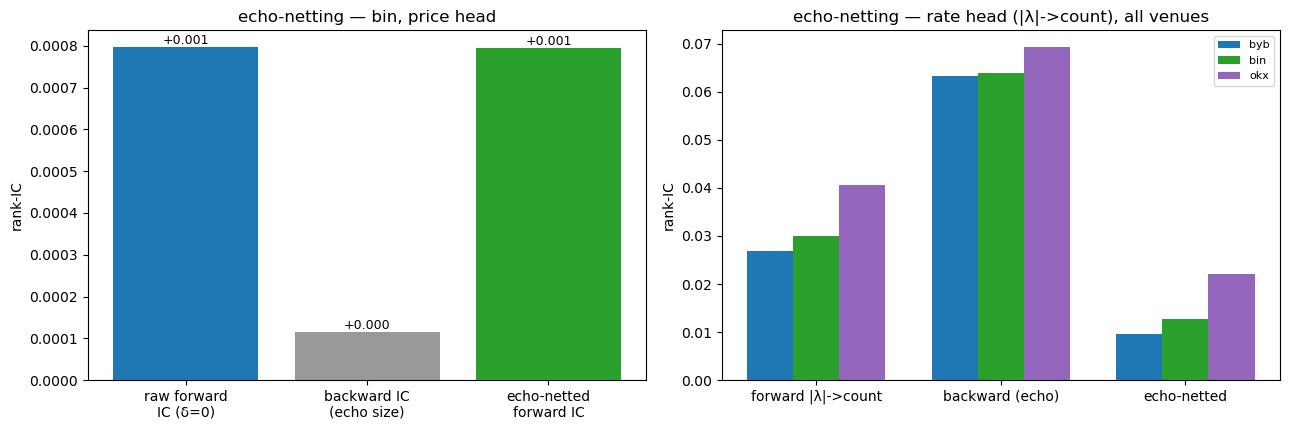

PRICE head (bin):  raw forward IC +0.001;  backward (echo) IC +0.000;  echo-netted forward IC +0.001  (the raw->netted shortfall is echo)
RATE head (|λ| -> byb move-count, per venue) — forward / backward(echo) / echo-netted forward IC:
  byb:  forward +0.027   backward +0.063   echo-netted +0.010  (echo-heavy: backward > forward)
  bin:  forward +0.030   backward +0.064   echo-netted +0.013  (echo-heavy: backward > forward)
  okx:  forward +0.041   backward +0.069   echo-netted +0.022  (echo-heavy: backward > forward)


In [11]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
rep_ex = OTHERS[0]                                       # one venue to illustrate; every feature carries its own
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

signed = kyle_lambda(rep_ex, SPANS[price_member[rep_ex]])   # the chosen price-head feature for this venue (signed λ at its price-span pick)
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

# === RATE HEAD echo-netting, PER VENUE — λ's HEADLINE head ===
# The price-head leg above is one venue, signed λ vs the forward RETURN. λ actually lives in the RATE head:
# |λ| at the rate-span pick vs byb's forward move-COUNT. So we net THAT echo too, per venue, with the SAME
# partial-IC tool — control = the TRAILING move-count [anchor-100ms, anchor] (the count already underway),
# scored against the FORWARD move-count [anchor, anchor+100ms]. backward IC sizes the echo; the echo-netted
# forward IC is what survives once the trailing count is partialled out. These are the numbers §10 quotes.
trail_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")]
               - cum_mv[np.searchsorted(byb_rx, anchor_ts - HORIZON_NS, "right")])   # byb moves over the PRIOR 100 ms (the echo)
rate_echo = {}
for ex in EX_LIST:
    m = np.abs(feat_cache[(ex, SPANS[rate_member[ex]])])      # |λ| at this venue's rate-span pick (the rate-head diagnostic)
    fwd_ic_e = _ic(m, fwd_count.astype(float))                # forward |λ|->count IC (the univariate edge from §6)
    bwd_ic_e = _ic(m, trail_count.astype(float))              # backward |λ|->count IC — the contemporaneous count echo
    net_ic_e = _partial_ic(m, fwd_count.astype(float), trail_count.astype(float))   # echo-netted forward count IC
    rate_echo[ex] = (fwd_ic_e, bwd_ic_e, net_ic_e)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
labels = ["raw forward\nIC (δ=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = axes[0].bar(labels, vals, color=["C0", "0.6", "C2"])
axes[0].axhline(0, color="0.7", lw=0.8); axes[0].set_ylabel("rank-IC"); axes[0].set_title(f"echo-netting — {rep_ex}, price head")
for b, v in zip(bars, vals):
    axes[0].text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
x = np.arange(3); w = 0.25
for k, ex in enumerate(EX_LIST):
    axes[1].bar(x + (k - 1) * w, rate_echo[ex], w, color=col[ex], label=ex)
axes[1].axhline(0, color="0.7", lw=0.8); axes[1].set_xticks(x)
axes[1].set_xticklabels(["forward |λ|->count", "backward (echo)", "echo-netted"])
axes[1].set_ylabel("rank-IC"); axes[1].set_title("echo-netting — rate head (|λ|->count), all venues"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()
print(f"PRICE head ({rep_ex}):  raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")
print("RATE head (|λ| -> byb move-count, per venue) — forward / backward(echo) / echo-netted forward IC:")
for ex in EX_LIST:
    f_e, b_e, n_e = rate_echo[ex]
    print(f"  {ex}:  forward {f_e:+.3f}   backward {b_e:+.3f}   echo-netted {n_e:+.3f}  ({'echo-heavy: backward > forward' if abs(b_e) > abs(f_e) else 'forward-dominant'})")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor−100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**The rate head is exactly this case, per venue.** The cell's right panel nets `|λ|`'s forward move-count IC of
the trailing-count echo: on this block **every** venue's backward IC *exceeds* its forward IC
(byb +0.063 > +0.027, bin +0.064 > +0.030, okx +0.069 > +0.041), so most of the apparent forward edge is the
move-count already underway. Once that is partialled out the genuinely-forward `|λ|`→count IC shrinks to
**+0.010 byb / +0.013 bin / +0.022 okx** — small, positive, echo-heavy. These are the numbers the §10 verdict
cites; the own-book **byb** leg sheds the most, since its `q·Δlogmid` is byb flow against byb's *same-interval*
move (the tightest echo).

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100–160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by
the feature and look at the real distributions the two heads care about:
- **rate head** (the headline): how the number of upcoming moves grows as |λ| grows;
- **price head** (secondary): byb's next return for low / middle / high *signed* λ.

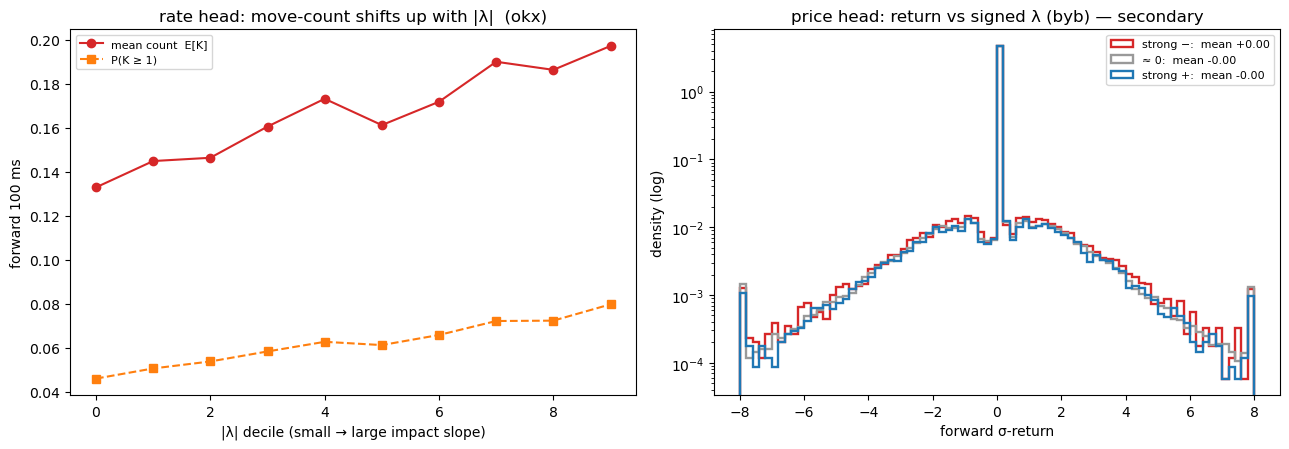

In [12]:
rep_ex = "okx"                                                                 # okx's cross-venue λ illustrates the shape; the model uses every venue
absmag = np.abs(feat_cache[(rep_ex, SPANS[rate_member[rep_ex]])])              # rate-head span
signed = feat_cache[("byb", SPANS[price_member["byb"]])]                       # price-head span, byb (own-book direction read)
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# rate head (headline): forward move-count shifts up with |λ|
fin = np.isfinite(absmag)
dec = np.full(absmag.shape, -1); dec[fin] = np.digitize(absmag[fin], np.nanpercentile(absmag[fin], np.arange(10, 100, 10)))
axA.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axA.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axA.set_xlabel("|λ| decile (small → large impact slope)"); axA.set_ylabel("forward 100 ms")
axA.set_title(f"rate head: move-count shifts up with |λ|  ({rep_ex})"); axA.legend(fontsize=8)

# price head (secondary): forward σ-return distribution across signed-λ buckets
# raw fwd_count above is shown for intuition; the rate head's actual target is rate_target = fwd_count / λ_ev (count ÷ λ_ev)
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"), ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, c in groups:
    mm = m & np.isfinite(target)
    axB.hist(np.clip(target[mm], -8, 8), bins=bins, density=True, histtype="step", color=c, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[mm]):+.2f}")
axB.set_yscale("log"); axB.set_xlabel("forward σ-return"); axB.set_ylabel("density (log)")
axB.set_title("price head: return vs signed λ (byb) — secondary"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the two heads care about (shown here for
okx's cross-venue λ on the rate head and byb's own-book λ on the price head; the model uses every venue).
**Rate head (left):** read whether the mean move-count `E[K]` and `P(K ≥ 1)` climb with the |λ| decile — a
higher impact slope preceding more byb moves is the headline mechanism §1 predicts. **Price head (right):**
signed λ's tilt on the forward return is the secondary, weaker read — read the group means in the legend for
how much the distribution shifts with the sign. The directions are those §1 predicted (larger |λ| → busier;
λ's sign a faint impact-direction lean).

## 8. Input shaping for the network

This is a *different* step from §2/§6. There the question was whether to divide out volatility (the "regime
division") — and Gate A measured λ's scale and decided. Here we reshape *that* feature for the network —
roughly centred, unit-scale, no wild outliers. λ is a ratio of two EMAs, so it can have a heavy tail when the
denominator `EMA(q²)` goes small (the ε is too tiny to floor it), so we expect more than a plain z-score.

Pick the **lightest** transform that does the job. Plot the feature (left) and compare a few candidates by how
close to a clean bell curve they make it (right — points on the diagonal are perfectly normal). A symmetric,
mild feature only needs a simple rescale; a heavily skewed or fat-tailed one needs more (a robust z-score +
clip, or a rank-to-normal map). The QQ-plot makes the choice.

feature: std=4.1e-07  skew=+6.10  excess_kurt=263.0  (0 = normal)
  z-score            excess_kurt=   263.0   max|·|=55.0
  robust + clip ±4   excess_kurt=    -0.5   max|·|=4.0
  arcsinh(robust)    excess_kurt=     1.0   max|·|=9.9
  rank-Gaussian      excess_kurt=    -0.0   max|·|=4.6


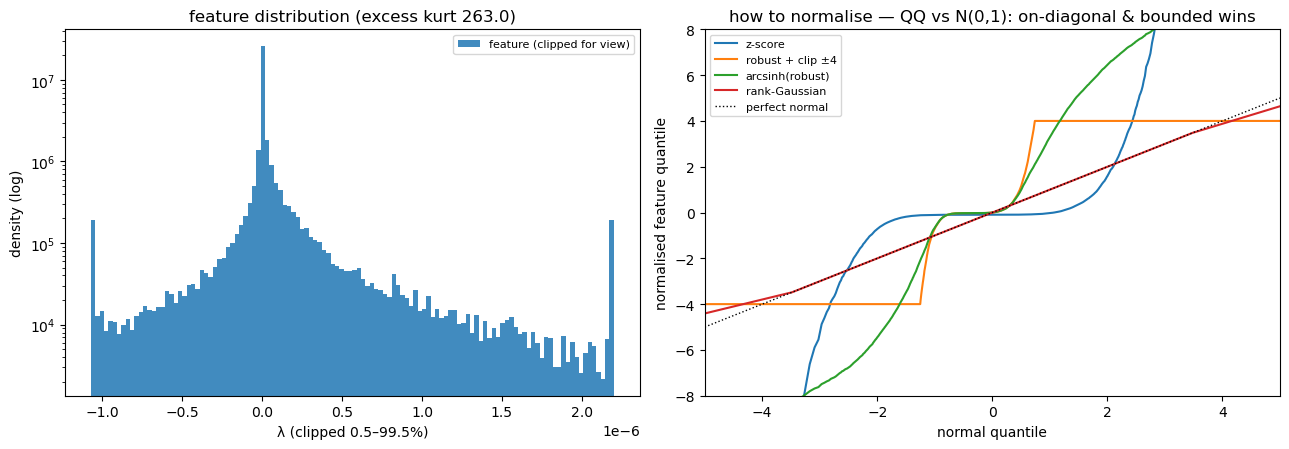

In [13]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_ex = "okx"
f = feat_cache[(rep_ex, SPANS[rate_member[rep_ex]])]; f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-30; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-30),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature: std={f.std():.2g}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>8.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
lo_p, hi_p = np.percentile(f, [0.5, 99.5])
axA.hist(np.clip(f, lo_p, hi_p), bins=120, density=True, color="C0", alpha=.85, label="feature (clipped for view)")
axA.set_yscale("log"); axA.set_xlabel("λ (clipped 0.5–99.5%)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution (excess kurt {kurtosis(f):.1f})"); axA.legend(fontsize=8)
q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub_q = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub_q], np.sort(v)[sub_q], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_ylim(-8, 8); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles the transform. As a ratio of two EMAs, λ has a violently fat tail (the
denominator `EMA(q²)` occasionally goes small — the ε is ~1e-6 of typical S, too tiny to floor it — blowing
the slope up): **skew +6.1, excess kurtosis 263**. A plain z-score leaves a **≈55σ** spike (max|·| = 55.0),
far past the "no wild outliers" bar. The lightest transform that *meets* it is a robust z-score followed by a
clip (**robust + clip ±4 → max|·| = 4.0, excess kurt −0.5**); rank-Gaussian also tames it (max|·| 4.6, excess
kurt ≈0) but throws away the magnitude gradations. The QQ-plot points to the on-diagonal, bounded curve; use
robust-z + clip whenever you feed a network. (This is the opposite of a bounded `[−1,1]` ratio, which needs no
clip — λ's units and ratio-of-moments shape make it the fat-tailed case.)

**Still to run** (same machinery): whether the feature adds over features we already have; whether the signal
is steady day-to-day; and whether it survives out-of-sample across a market-regime change. (The leak check
*inside* volatility buckets is no longer pending — Gate A's checks and the regime-stable companion now run it.)

## 9. When is per-exchange worth it? (for poolable features)

Kyle's λ is **poolable** — every venue yields its own one-number impact slope from its own signed flow vs
byb's mid — so the pool / single / per-venue choice is real here (unlike the template's cross-venue gap, which
has no single pooled version). The answer depends on the time-scale, so sweep it and compare the three:
- **pooled** — one λ over *all* venues' signed flow on the shared clock (sum the per-tick `q·Δlogmid` and
  `q²` across venues, then the same EMA-ratio);
- **best single** — the single most predictive venue's λ (in-sample pick, scored OOS);
- **per-venue** — all three fed in together.

We score each by **marginal walk-forward** rank-IC over the controls, **against the rate target** (λ's
headline head — |λ| → count), at a short, a medium, and a long span, to see where keeping the venues separate
pays off. (We use |λ| for the pooled/single/per-venue legs, matching the rate-head diagnostic.)

In [14]:
# pooled λ: sum signed_flow·Δlogmid and signed_flow² across ALL venues per clock tick, then the same C/(S+ε) EMA-ratio.
# ε for the pool: the same EPS_FRAC fraction of the pooled median q² (a single hyperparameter, like the per-venue ε).
pool_cross = sum(cross[ex] for ex in EX_LIST); pool_sq2 = sum(sq2[ex] for ex in EX_LIST)
EPS_POOL = EPS_FRAC * np.median(pool_sq2[pool_sq2 > 0])
def pooled_lambda(N):
    Cp = _ema_tick(pool_cross, N)[tick_at_anchor]; Sp = _ema_tick(pool_sq2, N)[tick_at_anchor]
    return Cp / (Sp + EPS_POOL)

scan = [("short", SPANS[0]), ("medium", SPANS[2]), ("long", SPANS[4])]   # 50 / 500 / 5000 trades
rows = []
for label, N in scan:
    per_ex = [np.abs(kyle_lambda(ex, N)) for ex in EX_LIST]                                          # |λ| per venue (rate-head diagnostic)
    single_ic = {ex: wf_ic(base + [np.abs(kyle_lambda(ex, N))], rate_target) - wf_ic(base, rate_target) for ex in EX_LIST}
    best_ex = max(single_ic, key=single_ic.get)
    pooled  = round(wf_ic(base + [np.abs(pooled_lambda(N))], rate_target) - wf_ic(base, rate_target), 3)
    single  = round(single_ic[best_ex], 3)
    perex   = round(wf_ic(base + per_ex, rate_target) - wf_ic(base, rate_target), 3)
    rows.append(dict(time_scale=f"{label} (N={N})", pooled=pooled, best_single=f"{single} ({best_ex})", per_venue=perex))
pl.DataFrame(rows)

time_scale,pooled,best_single,per_venue
str,f64,str,f64
"""short (N=50)""",-0.001,"""-0.0 (okx)""",-0.001
"""medium (N=500)""",-0.0,"""-0.0 (byb)""",-0.001
"""long (N=5000)""",-0.0,"""0.0 (bin)""",0.0


**Conclusion.** Marginal walk-forward rank-IC over the controls (against the |λ| → count rate target) for
**pooled** vs **best single** vs **per-venue**, at a short / medium / long span. On this block **all three are
≈ 0 at every scale** (short pooled −0.001, single −0.000 okx, per-venue −0.001; medium pooled −0.0, single
−0.0 byb, per-venue −0.001; long pooled −0.0, single +0.0 bin, per-venue +0.0). This is exactly what §6
found: λ's univariate forward edge is *real* but, once the rate controls are in, its **marginal is ≈0 in every
configuration** — pooling, collapsing to one venue, or keeping all three makes no difference, because the
impact slope is collinear with the rate regime the controls already encode. So the pool/single/per-venue
choice is **moot here** — none adds over the controls. We still keep **all venues** as the safe default (the
extra venues never hurt and capture the rotating lead if a future block gives λ a marginal), but on this block
this comparison is **diagnostic, not a ship-decider** — it replaces a hand-waved table with a measured ≈0.

## 10. The verdict, and what it takes to ship

**The honest disposition: a real but redundant, rate-shaped feature whose *marginal* edge
over the rate controls is ≈ 0 on this block — keep it as a candidate, do NOT claim a standalone edge.** (All
numbers are read off the printed cells of *this* run; every IC names the target it is against.) If used, feed
the *signed* λ to both heads (each head gated separately in §6); the rate head recovers |λ| and learns how
venues' impacts cancel or reinforce — never feed a pre-computed `|λ|` per venue.
- **Rate head (intensity — λ's headline head).** |λ| has a genuine *univariate* forward IC to byb's move-count
  — **+0.027 byb / +0.029 bin / +0.040 okx** at N=50 (a slow liquidity-state gauge). **Two honest deflations:** (i) the **echo-netted** forward IC (partial,
  controlling for the trailing move-count) shrinks to **+0.010 byb / +0.013 bin / +0.022 okx** (each leg
  echo-heavy, backward IC > forward) — the own-book byb leg loses the most (its `q·Δlogmid` is byb flow ×
  byb's *same-interval* move); and (ii) the gate that counts — |λ|'s **marginal** add over the rate/vol
  controls against the **count** target — is ≈ **0** (joint **−0.001**, per-venue −0.000/−0.001/−0.000,
  positive in 0/5 folds), because the rate controls already carry the autocorrelated byb move-rate and |λ| is
  collinear with them. (Within-λ_ev strata the within-stratum signal is still positive — 0.018/0.004/0.01 —
  so the ≈0 marginal is real collinearity, not a `1/λ_ev` artefact.) Pick a **short span (N=50)** if used.
- **Price head (direction) — absent.** Signed λ's sign is a noisy impact-direction read: marginal over the
  controls **−0.001** (joint, 1/5 folds), echo-netted ≈ −0.001/+0.001/−0.002. λ is a rate-shaped feature, not
  a direction one.
- **Cross-venue / pooling (§9).** λ is poolable; the pool / single / per-venue sweep (against the |λ|→count
  rate target) is **≈ 0 in every configuration at every scale** — the choice is moot here because λ's marginal
  is ≈0 regardless. Diagnostic, not a ship-decider; the per-venue split costs nothing (all venues kept).

**Raw-vs-normalise (decided on the measured Gate-A number, §6).** λ is a regression *slope* with units, so we
**measured** its scale across volatility buckets, **per venue**, in Gate A. For the **rate-span (N=50)**
feature — the head λ actually feeds — scale **passes** on every venue (**1.71 / 1.57 / 1.53×**, all ≪ 3),
because a slope is a *ratio* of two co-moving moments and the regime largely cancels, so λ ships **raw** (no
σ-division). *(For the price-span feature okx's scale brushes/exceeds the 3× bar at 3.16× — but the price head
carries no signal anyway, so that's moot. The non-monotone dispersion is high on every venue — 0.16–0.29 —
the same redundancy story: |λ| leaks the rate regime.)* We do *not* divide by `σ_ev` reflexively. (If a future
block pushes the rate-span scale over 3×, dividing by `σ_ev` is the documented fallback.)

**Cite the echo-netted IC for any echo-heavy leg.** The headline δ=0 IC over-credits the move already
underway; the **echo-netted (partial) forward IC** is the number to quote for any leg whose backward IC is ≥
its forward IC — on this block *every* rate leg is backward-echo-heavy, so the netted +0.010/+0.013/+0.022 is
what λ's rate verdict stands on, not the raw +0.027/+0.029/+0.040.

**Clock choice (stated plainly).** λ is two **flow EMAs** — the cross-moment `EMA(q·Δlogmid)` and the second
moment `EMA(q²)` — **injected once per trade-timestamp** (the interval's net signed flow `q` and byb's
`Δlogmid`) and **decayed once per trade-timestamp** on the shared bin/byb/okx merged trade clock
(`merged_ts = np.unique(...)`, simultaneous prints = one tick = one interval = one decay), read as the ratio
`C/(S+ε)`. λ is read at the **last committed trade tick ≤ the anchor** — frozen between trades, *not* a live
front (more conservative than a forward-filled gap, never a leak); ε is a fixed global constant.

**To ship:**
- [x] the streaming (constant-work-per-trade) builder, matching this analysis version — **done, §4 parity is to
      floating precision on a real block (shipped N=50 AND a long N=5000, all three venues, over the whole block)**
- [ ] the parity check (§4) and tests, passing
- [x] the gate results recorded **honestly**: Gate A scale ships RAW on the rate-span feature (1.5–1.7× ≪ 3,
      decided on the measured per-venue number; dispersion high — the redundancy story); univariate forward
      rate IC real (+0.027/+0.029/+0.040) but **echo-netted smaller** (+0.010/+0.013/+0.022);
      **marginal value over the rate controls ≈ 0** (joint −0.001, 0/5 folds — collinear / backward-echo
      dominated); price head absent; §9 pool/single/per-venue all ≈0 (measured, the honest failure to record)
- [ ] the chosen heads and spans written down, with the yardstick span (YARDSTICK_N=10000) and ε (a fixed
      global constant, disclosed as non-causal and too small to floor the denominator)
- [ ] the data quirks handled (bad zero-price/zero-qty prints filtered; venue-aware aggressor sign via
      `io._trade_lifts_ask`; same-ns prints = one interval)
- [ ] **a clear marginal edge over the rate controls** — modest on this block; keep λ as a candidate
      (rotation across blocks), re-test on more blocks / against a feature set that excludes the rate controls
      before shipping as a standalone input